Student Name : Lokesh Thapa

Student Number : 2408486

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np

In [12]:
from google.colab import drive
import zipfile

# Mount drive
drive.mount('/content/drive')

# Correct path
zip_path = '/content/drive/MyDrive/AI/Data/Copy of FruitinAmazon.zip'
extract_path = 'dataset'

# Extract
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction complete!")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Extraction complete!


# Identifying dataset classes

In [13]:
train_dir = "dataset/FruitinAmazon/train"

#getting the class name/subdirectories
class_names = sorted(os.listdir(train_dir))

print("Dataset name: ",os.listdir("dataset"))

if not class_names:
  print("No class directories foiunf in the train folder!!")
else:
  print("Class names:",class_names)



Dataset name:  ['FruitinAmazon']
Class names: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']


# Visualizing sample images

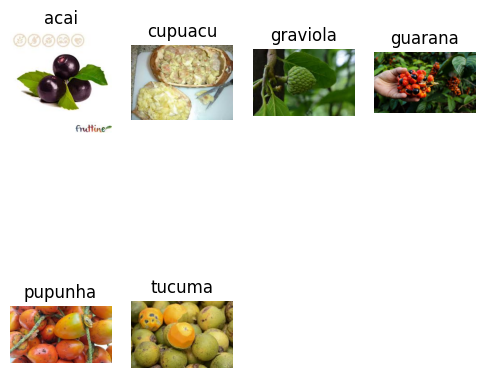

In [14]:
import random
import matplotlib.pyplot as plt
from PIL import Image

classes = sorted(os.listdir(train_dir))

plt.figure(figsize=(6,6))
#this is to display one random image from each class
for i, cls in enumerate(classes):
    class_path = os.path.join(train_dir, cls)
    img_name = random.choice(os.listdir(class_path))
    img_path = os.path.join(class_path, img_name)

    img = Image.open(img_path)

    plt.subplot(2, (len(classes)//2)+1, i+1)
    plt.imshow(img)
    plt.title(cls)
    plt.axis("off")

plt.show()

The dataset contains images grouped into class folders. Each folder represents a fruit category. The images vary in orientation, lighting, and background but share common visual features that help the CNN learn patterns.

In [15]:
from PIL import Image,UnidentifiedImageError

corrupted_images = [] #list to store all the corrupted images
#looping through each class folder and cheking for the corrupted images
for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir,class_name)
    if os.path.isdir(class_path):  #ensuring it is a valid directory
      images = os.listdir(class_path)
      for file in os.listdir(class_path):
        image_path = os.path.join(class_path,file)
        try:
            with Image.open(image_path) as img:
              img.verify() #verifying if image can be opened correctly

        except (IOError, UnidentifiedImageError):

                corrupted_images.append(image_path)
                os.remove(image_path)
                print(f"Removed corrupted image: {image_path}")

if corrupted_images:
    print("Corrupted images found:")
    for img in corrupted_images:
        print(img)
else:
  print("No corrupted images found.")

No corrupted images found.


# Checking class imbalance

In [16]:
#dictionary to store the number of images in each class
class_counts = {}

for class_name in class_names:
  class_path = os.path.join(train_dir, class_name)
  if os.path.isdir(class_path):
    images = [img for img in os.listdir(class_path) if img.lower().endswith(('.png','.jpg','jpeg'))]
    class_counts[class_name] = len(images) #counts images in each class

#printing class imbalance
print("\nClass Distribution:")
print("=" * 45)
print(f"{'Class Name':<25}{'Valid image count':>15}")
print("=" * 45)
for class_name, count in class_counts.items():
    print(f"{class_name:<25}{count:>15}")
print("="* 45)


Class Distribution:
Class Name               Valid image count
acai                                  15
cupuacu                               15
graviola                              15
guarana                               15
pupunha                               15
tucuma                                15


# Random Image Selection

In [17]:
import random
selected_images = [] # Store image paths
selected_labels = [] # Store corresponding class names
for class_name in class_names:
  class_path = os.path.join(train_dir, class_name)
  if os.path.isdir(class_path):
    images = [img for img in os.listdir(class_path) if img.lower().endswith(('.png', '.jpg', '.jpeg'))]
    if images: # Ensure the class folder is not empty
      selected_img = os.path.join(class_path, random.choice(images))
      selected_images.append(selected_img)
      selected_labels.append(class_name)

# Random image Plot


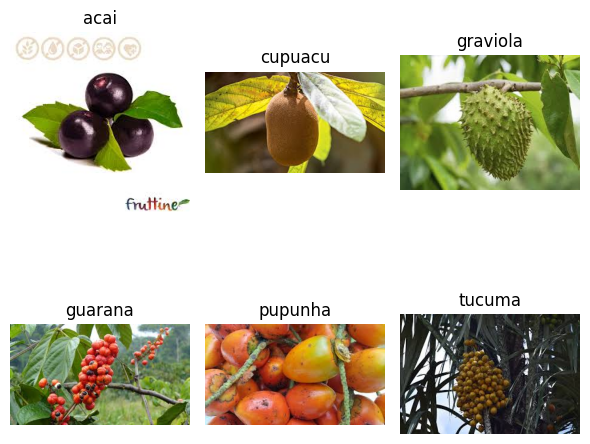

In [18]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
# Determine grid size
num_classes = len(selected_images)
cols = (num_classes + 1) // 2 # Determine columns
rows = 2 # Fixed rows for layout
fig, axes = plt.subplots(rows, cols, figsize=(6, 6))
for i, ax in enumerate(axes.flat):
  if i < num_classes:
    img = mpimg.imread(selected_images[i])
    ax.imshow(img)
    ax.set_title(selected_labels[i])
    ax.axis("off")
  else:
    ax.axis("off") # Hide empty subplots
plt.tight_layout()
plt.show()

# Data loading and preprocessing

In [19]:
import tensorflow as tf

img_height = 224
img_width = 224
batch_size = 32
validation_split = 0.2
#normalizing pixel values from 0-255 to 0-1
rescale = tf.keras.layers.Rescaling(1./255)

train_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height,img_width),
    batch_size=batch_size,
    shuffle=True,
    validation_split=validation_split,
    subset='training',
    seed=123
)
#loading validation dataset
val_ds = tf.keras.preprocessing.image_dataset_from_directory(
    train_dir,
    labels='inferred',
    label_mode='int',
    image_size=(img_height,img_width),
    batch_size=batch_size,
    shuffle=False,
    validation_split=validation_split,
    subset='validation',
    seed=123
)
#applying normalization to datasets
train_ds = train_ds.map(lambda x,y:(rescale(x),y))
val_ds = val_ds.map(lambda x,y:(rescale(x),y))

Found 90 files belonging to 6 classes.
Using 72 files for training.
Found 90 files belonging to 6 classes.
Using 18 files for validation.


# Data Augmentation

In [20]:
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

data_augmentation_layers = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
]

def data_augmentation(images):
    for layer in data_augmentation_layers:
        images = layer(images)
    return images

# CNN model Task 1

In [32]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, BatchNormalization
from tensorflow.keras.layers import Dropout, Dense, Flatten
from tensorflow.keras import layers

# Define data augmentation as a Sequential model (moved from cell BNgPiC6WdcjR)
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.1),
    tf.keras.layers.RandomZoom(0.1),
])

model = Sequential([

    # Data augmentation layer
    data_augmentation,

    # Block 1
    Conv2D(32, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    # Block 2
    Conv2D(64, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    # Block 3
    Conv2D(128, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    # Block 4
    Conv2D(256, (3,3), padding='same', activation='relu'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    # Flatten
    Flatten(),

    # Fully connected layer
    Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),

    # Output layer
    Dense(len(class_names), activation='softmax')
])

In [22]:
model.compile(
optimizer='adam',
loss='sparse_categorical_crossentropy',
metrics=['accuracy']
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     6,422,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴─────────────

 Total params: 6,814,278 (25.99 MB)

 Trainable params: 6,813,062 (25.99 MB)

 Non-trainable params: 1,216 (4.75 KB)

In [33]:
# The data_augmentation Sequential model definition has been moved to the model creation cell (hOAy4Op6U03m).

In [24]:
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

# Save the best model during training
checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

# Stop training if validation loss does not improve
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True,
    verbose=1
)

# Train the model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=50,
    callbacks=[checkpoint, early_stop]
)

Epoch 1/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 3s/step - accuracy: 0.2477 - loss: 2.8948
Epoch 1: val_loss improved from None to 1.69141, saving model to best_model.keras

Epoch 1: finished saving model to best_model.keras
3/3 ━━━━━━━━━━━━━━━━━━━━ 15s 3s/step - accuracy: 0.3056 - loss: 2.5685 - val_accuracy: 0.1667 - val_loss: 1.6914
Epoch 2/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.4792 - loss: 1.4020
Epoch 2: val_loss did not improve from 1.69141
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 3s/step - accuracy: 0.5000 - loss: 1.3060 - val_accuracy: 0.0000e+00 - val_loss: 1.9269
Epoch 3/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5966 - loss: 1.0567
Epoch 3: val_loss did not improve from 1.69141
3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step - accuracy: 0.5556 - loss: 1.1853 - val_accuracy: 0.0000e+00 - val_loss: 3.3757
Epoch 4/50
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 2s/step - accuracy: 0.5845 - loss: 1.1253
Epoch 4: val_loss did not improve from 1.69141
3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step - accuracy: 0.5972

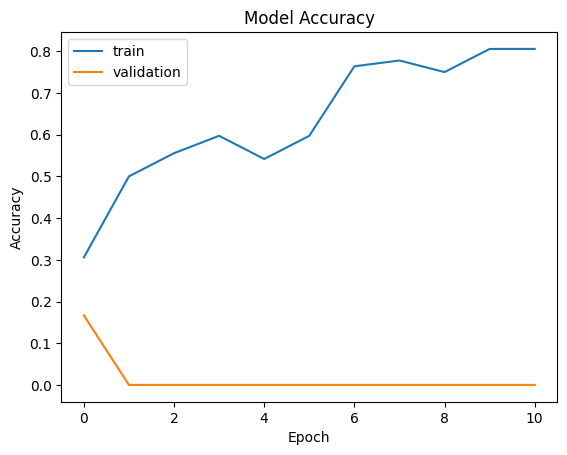

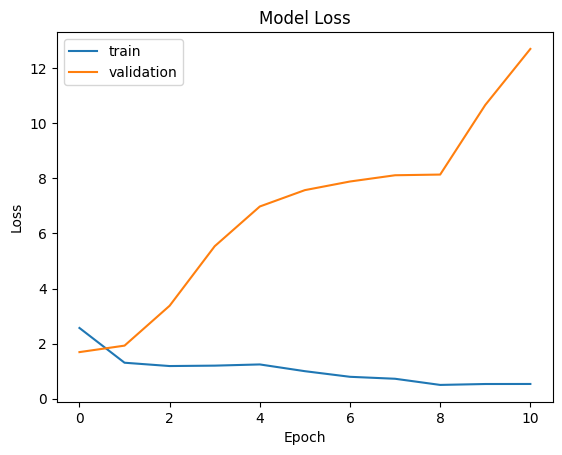

In [25]:
plt.plot(history.history['accuracy'],label='train')
plt.plot(history.history['val_accuracy'],label='validation')

plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()


plt.plot(history.history['loss'],label='train')
plt.plot(history.history['val_loss'],label='validation')

plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [26]:
test_loss,test_acc = model.evaluate(val_ds)

print("Test Accuracy:",test_acc)
print("Test Loss:",test_loss)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 0.1667 - loss: 1.6914
Test Accuracy: 0.1666666716337204
Test Loss: 1.6914050579071045


In [28]:
def data_augmentation(x):
    # Example (adjust based on your original code)
    import tensorflow as tf
    x = tf.image.random_flip_left_right(x)
    x = tf.image.random_brightness(x, 0.2)
    return x

In [30]:
from tensorflow.keras.models import load_model

model = load_model('fruit_cnn_model.keras', custom_objects={
    'data_augmentation': data_augmentation
})

In [35]:
# Save the trained model
model.save("fruit_cnn_model.keras")

# Load the saved model
from tensorflow.keras.models import load_model
loaded_model = load_model("fruit_cnn_model.keras")

# Recompile the loaded model
loaded_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Evaluate the loaded model
loss, accuracy = loaded_model.evaluate(val_ds)

print("Loaded Model Accuracy:", accuracy)
print("Loaded Model Loss:", loss)

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_api.py:107: UserWarning: You are saving a model that has not yet been built. It might not contain any weights yet. Consider building the model first by calling it on some data.
  return saving_lib.save_model(model, filepath)


1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - accuracy: 0.1667 - loss: 1.7621
Loaded Model Accuracy: 0.1666666716337204
Loaded Model Loss: 1.762083649635315


In [36]:
import numpy as np
from sklearn.metrics import classification_report

y_true = []
y_pred = []

for images,labels in val_ds:

    predictions = loaded_model.predict(images)

    pred_labels = np.argmax(predictions,axis=1)

    y_true.extend(labels.numpy())
    y_pred.extend(pred_labels)
unique_labels = np.unique(y_true)

print(classification_report(y_true,y_pred, labels=unique_labels,target_names=[classes[i] for i in unique_labels]))

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 681ms/step
              precision    recall  f1-score   support

     pupunha       0.12      0.67      0.21         3
      tucuma       0.50      0.07      0.12        15

    accuracy                           0.17        18
   macro avg       0.31      0.37      0.16        18
weighted avg       0.44      0.17      0.13        18



# Transfer Learning (VGG16)

In [37]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Flatten

# Load Pretrained VGG16 Model

In [38]:
base_model = VGG16(
    weights='imagenet',
    include_top=False,
    input_shape=(224,224,3)
)

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


# Freeze pretrained layers

In [39]:
for layer in base_model.layers:
    layer.trainable = False

# Build Transfer Learning Model

In [40]:
model_transfer = Sequential([

    base_model,

    Flatten(),

    Dense(256, activation='relu'),

    Dense(len(class_names), activation='softmax')
])

# Compile the Model

In [41]:
model_transfer.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train the Model

In [44]:
history_transfer = model_transfer.fit(
    train_ds,
    validation_data=val_ds,
    epochs=15
)

Epoch 1/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 38s 13s/step - accuracy: 0.8750 - loss: 0.3183 - val_accuracy: 0.8889 - val_loss: 0.3616
Epoch 2/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 34s 11s/step - accuracy: 0.9861 - loss: 0.1312 - val_accuracy: 0.8889 - val_loss: 0.2317
Epoch 3/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 44s 13s/step - accuracy: 0.9722 - loss: 0.1503 - val_accuracy: 0.8889 - val_loss: 0.1934
Epoch 4/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 41s 13s/step - accuracy: 1.0000 - loss: 0.0657 - val_accuracy: 0.8889 - val_loss: 0.1885
Epoch 5/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 37s 13s/step - accuracy: 1.0000 - loss: 0.0231 - val_accuracy: 0.8889 - val_loss: 0.2104
Epoch 6/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 38s 11s/step - accuracy: 1.0000 - loss: 0.0143 - val_accuracy: 0.9444 - val_loss: 0.2428
Epoch 7/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 38s 13s/step - accuracy: 1.0000 - loss: 0.0131 - val_accuracy: 0.9444 - val_loss: 0.2624
Epoch 8/15
3/3 ━━━━━━━━━━━━━━━━━━━━ 38s 13s/step - accuracy: 1.0000 - loss: 0.0106 - val_accuracy: 0.9444 - val_loss: 0.2604


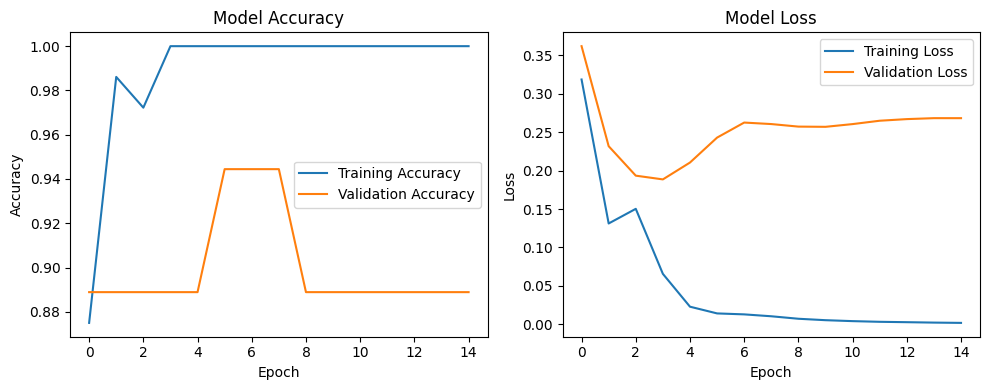

In [45]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

# Accuracy graph
plt.subplot(1,2,1)
plt.plot(history_transfer.history['accuracy'], label='Training Accuracy')
plt.plot(history_transfer.history['val_accuracy'], label='Validation Accuracy')
plt.title("Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()

# Loss graph
plt.subplot(1,2,2)
plt.plot(history_transfer.history['loss'], label='Training Loss')
plt.plot(history_transfer.history['val_loss'], label='Validation Loss')
plt.title("Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()

plt.tight_layout()
plt.show()

# Evaluate the Model

In [46]:
loss, accuracy = model_transfer.evaluate(val_ds)

print("Transfer Learning Accuracy:", accuracy)
print("Transfer Learning Loss:", loss)

1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step - accuracy: 0.8889 - loss: 0.2681
Transfer Learning Accuracy: 0.8888888955116272
Transfer Learning Loss: 0.26807013154029846


# Fine-Tuning

In [47]:
base_model.trainable = True

for layer in base_model.layers[:-4]:
    layer.trainable = False

# Recompile with smaller learning rate

In [48]:
from tensorflow.keras.optimizers import RMSprop

model_transfer.compile(
    optimizer=RMSprop(learning_rate=1e-5),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

# Train Fine-Tuned Model

In [49]:
history_finetune = model_transfer.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10
)

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 36s 11s/step - accuracy: 1.0000 - loss: 0.0018 - val_accuracy: 0.8889 - val_loss: 0.2676
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 34s 11s/step - accuracy: 1.0000 - loss: 0.0017 - val_accuracy: 0.8889 - val_loss: 0.2674
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 35s 11s/step - accuracy: 1.0000 - loss: 0.0017 - val_accuracy: 0.8889 - val_loss: 0.2673
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 38s 13s/step - accuracy: 1.0000 - loss: 0.0017 - val_accuracy: 0.8889 - val_loss: 0.2672
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 38s 11s/step - accuracy: 1.0000 - loss: 0.0017 - val_accuracy: 0.8889 - val_loss: 0.2673
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 35s 11s/step - accuracy: 1.0000 - loss: 0.0016 - val_accuracy: 0.8889 - val_loss: 0.2675
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 44s 13s/step - accuracy: 1.0000 - loss: 0.0016 - val_accuracy: 0.8889 - val_loss: 0.2676
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 38s 13s/step - accuracy: 1.0000 - loss: 0.0016 - val_accuracy: 0.8889 - val_loss: 0.2678


# Final Evaluation

In [50]:
loss, accuracy = model_transfer.evaluate(val_ds)

print("Fine-Tuned Model Accuracy:", accuracy)

1/1 ━━━━━━━━━━━━━━━━━━━━ 7s 7s/step - accuracy: 0.8889 - loss: 0.2677
Fine-Tuned Model Accuracy: 0.8888888955116272
